<a href="https://colab.research.google.com/github/institutohumai/cursos-python/blob/master/MachineLearning/7_XGBoost/xgboost.ipynb"> <img src='https://colab.research.google.com/assets/colab-badge.svg' /> </a>
<div align="center"> Recordá abrir en una nueva pestaña </div>

# XGBoost

In [ ]:
!pip3 install -U scikit-learn --upgrade # necesitamos sklearn >= 0.24

In [ ]:
!pip install xgboost

In [ ]:
!pip install lightgbm

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.8 MB/s eta 0:00:00


In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 60.3 MB/s eta 0:00:00


In [ ]:
!pip install ipywidgets # puede ser necesario si lo corren local

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.8 MB/s eta 0:00:00


In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.6 MB/s eta 0:00:00


## Preintroducción

# 📌 Explicación de la Función Objetivo en XGBoost  

## 1️⃣ Contexto en XGBoost  
En XGBoost, la función objetivo se compone de dos partes:  
✅ La función de **pérdida** (qué tan mal está prediciendo el modelo).  
✅ La **regularización** (para controlar la complejidad del modelo y evitar sobreajuste).  

---

## 2️⃣ Expansión de Taylor: ¿Por qué?  
XGBoost usa **boosting**, lo que significa que construye el modelo en iteraciones (o etapas). En cada paso, queremos mejorar la predicción actual, agregando un nuevo árbol que minimice la pérdida.  

La función de pérdida $l(y_i, \hat{y}_i)$ mide qué tan mal están las predicciones. Sin embargo, trabajar con ella directamente puede ser complicado. Para simplificar el cálculo, se usa la **expansión de Taylor de segundo orden**, que nos da una aproximación cuadrática de la función de pérdida alrededor de la predicción actual $\hat{y}_i^{(t-1)}$.  

---

## 3️⃣ Desglose de la Fórmula  

$\sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$

📌 **Primera parte:**  
$g_i f_t(x_i)$  
* $g_i$ es el **gradiente** de la pérdida con respecto a la predicción anterior $\hat{y}_i^{(t-1)}$. Indica cuánto cambiar la predicción para reducir la pérdida.

* $f_t(x_i)$ es la nueva corrección que aporta el nuevo árbol.  

📌 **Segunda parte:**  
$\frac{1}{2} h_i f_t^2(x_i)$  
* $h_i$ es el **Hessiano** (segunda derivada de la pérdida). Ayuda a ajustar el paso del gradiente para evitar cambios demasiado grandes. El factor $\frac{1}{2}$ es por la expansión de Taylor.  

📌 **Tercera parte:**  
$\Omega(f_t)$  
Es la **regularización** para controlar la complejidad del árbol.  

---

## 4️⃣ Resumen en palabras simples  
1️⃣ Se usa Taylor para simplificar la función de pérdida.  
2️⃣ El término $g_i$ indica cuánto cambiar la predicción.  
3️⃣ El término $h_i$ ajusta ese cambio para evitar pasos inestables.  
4️⃣ Se suma la regularización para evitar árboles muy complejos.  

💡 **Conclusión:** En cada iteración, el nuevo árbol $f_t$ se ajusta usando estos términos, minimizando la función objetivo y mejorando las predicciones. 🚀  


# 📌 Descomposición de la Función de Pérdida en XGBoost

## 🎯 Objetivo  
Queremos descomponer la función de pérdida en XGBoost cuando usamos, por ejemplo, el **Error Cuadrático Medio (MSE)** como función de pérdida.  

La función MSE se define así:  

$l(y_i, \hat{y}_i) = \frac{1}{2} (y_i - \hat{y}_i)^2$

Donde:  
- $y_i$ es el valor real.  
- $\hat{y}_i$ es la predicción actual del modelo.  

---

##  1️⃣ Cálculo del Gradiente (Primera Derivada)  

Para mejorar la predicción, queremos saber **qué tanto cambiarla** para reducir el error.  
Eso se hace calculando la **primera derivada** (gradiente) con respecto a $\hat{y}_i$:  

$g_i = \frac{\partial}{\partial \hat{y}_i} \left( \frac{1}{2} (y_i - \hat{y}_i)^2 \right)$

Aplicamos la derivada:  

$g_i = - (y_i - \hat{y}_i)$

Esto nos dice **cuánto cambiar $\hat{y}_i$ para reducir el error**.  

✅ Si la predicción es mucho menor que el valor real, el gradiente es **negativo** → debemos **aumentar la predicción**.  
✅ Si la predicción es mucho mayor que el valor real, el gradiente es **positivo** → debemos **disminuir la predicción**.  

Evaluamos en la predicción anterior $\hat{y}_i^{(t-1)}$:  

$g_i = - (y_i - \hat{y}_i^{(t-1)})$

---

##  2️⃣ Cálculo del Hessiano (Segunda Derivada)  

La **segunda derivada** nos ayuda a ajustar el tamaño del cambio. Se llama **Hessiano** y se obtiene derivando el gradiente otra vez:  

$h_i = \frac{\partial^2}{\partial \hat{y}_i^2} \left( \frac{1}{2} (y_i - \hat{y}_i)^2 \right)$

Derivando otra vez:  

$h_i = 1$

En este caso, el Hessiano es simplemente **1**, lo que significa que no hay necesidad de ajustar el tamaño del paso (es constante).  

---

## 🔥 3️⃣ Sustitución en la Expansión de Taylor  

En XGBoost, la función de pérdida se **aproxima** con una expansión de Taylor de segundo orden:  

$\sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$

Sustituyamos los valores que encontramos:  

$\sum_{i=1}^{n} \left[ - (y_i - \hat{y}_i^{(t-1)}) f_t(x_i) + \frac{1}{2} f_t^2(x_i) \right] + \Omega(f_t)$

📌 **¿Qué significa esto?**  
- El primer término $- (y_i - \hat{y}_i^{(t-1)}) f_t(x_i)$ indica cuánto cambiar la predicción.  
- El segundo término $\frac{1}{2} f_t^2(x_i)$ ajusta el tamaño del cambio para que no sea demasiado brusco.  
- El término $\Omega(f_t)$ es la regularización para evitar árboles demasiado complejos.  

---

## ✅ Resumen final  

En cada iteración del modelo:  
1️⃣ Se calcula cuánto cambiar la predicción ( $g_i$, gradiente).  
2️⃣ Se ajusta el tamaño del cambio ($h_i$, Hessiano).  
3️⃣ Se minimiza la función objetivo para mejorar la predicción.  

🚀 **El modelo aprende a hacer mejores predicciones paso a paso usando esta aproximación.**  


## 💡 **Ejemplo Numérico Corregido con la Función Objetivo**  

### **Datos iniciales**  
- **Valor real**: $y = 5$  
- **Predicción anterior**: $\hat{y}^{(t-1)} = 3$  
- **Nueva función a aprender**: $f_t(x)$

Recordemos la forma general de la función objetivo en XGBoost:  

$\sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$

Donde:  
- $g_i$ es el **gradiente** (1ª derivada de la función de pérdida).  
- $h_i$ es el **Hessiano** (2ª derivada de la función de pérdida).  
- $f_t(x)$ es el nuevo ajuste que el modelo aprenderá en esta iteración.  

---  

### **1️⃣ Calculamos el Gradiente $g_i$**  
$g_i = - (y - \hat{y}^{(t-1)})$

$g_i = - (5 - 3) = -2$

---  

### **2️⃣ Calculamos el Hessiano $h_i$**  
Para **MSE**, la segunda derivada es siempre **1**:  

$h_i = 1$

---  

### **3️⃣ Encontramos el Mejor $f_t(x)$**  

En cada iteración, XGBoost encuentra el **mejor valor de $f_t(x)$** minimizando la función objetivo:  

$f_t(x) = - \frac{g_i}{h_i}$

Sustituyendo valores:  

$f_t(x) = - \frac{-2}{1} = 2$

---  

### **4️⃣ Calculamos la Nueva Predicción**  

La nueva predicción se obtiene sumando el ajuste $f_t(x)$ a la predicción anterior:  

$\hat{y}^{(t)} = \hat{y}^{(t-1)} + f_t(x)$

$\hat{y}^{(t)} = 3 + 2 = 5$

---  

### **✅ Resultado Final**  
**La nueva predicción es 5, que coincide con el valor real.** 🎯  

Así, XGBoost ha corregido su error en **una sola iteración** porque el problema era muy simple.  

---  

## 🚀 **Conclusión**  

👉 Aplicamos la fórmula correctamente:  

1️⃣ **Calculamos el gradiente** $g_i = -2$
2️⃣ **Calculamos el Hessiano** $h_i = 1$  
3️⃣ **Encontramos el mejor $f_t(x) ** f_t(x) = 2$  
4️⃣ **Ajustamos la predicción** $\hat{y}^{(t)} = 5$  

Este es el proceso que XGBoost sigue en cada iteración para mejorar sus predicciones.  

💡 **Nota:** Este ejemplo es muy sencillo, pero en problemas reales, hay muchas observaciones y el ajuste se hace en conjunto con regularización para evitar sobreajuste.  

---



## **¿Por qué la nueva fórmula es $g_i / h_i$?**  

La idea clave es que queremos encontrar el **mejor valor para $f_t(x)$** que minimice la función objetivo.  

Si tomamos la derivada de la función objetivo con respecto a $f_t(x)$ y la igualamos a **cero** para encontrar su punto mínimo, llegamos a la ecuación:  

$f_t(x) = - \frac{g_i}{h_i}$

Esto se debe a que $g_i$ representa la dirección del error (gradiente), mientras que $h_i$ representa la curvatura de la función de pérdida.  

Así que, al dividir $g_i$ por $h_i$, obtenemos el **mejor ajuste para minimizar la pérdida en esta iteración**.



# Regularización en XGBoost

La **regularización** en **XGBoost** es un proceso que ayuda a prevenir el sobreajuste (overfitting) en el modelo, controlando la complejidad del mismo. XGBoost, como otros modelos de machine learning, busca encontrar un equilibrio entre ajustar bien los datos de entrenamiento y mantener una buena capacidad de generalización a datos nuevos. La regularización es clave para evitar que el modelo se ajuste demasiado a los detalles específicos del conjunto de entrenamiento (lo que puede resultar en un modelo con un rendimiento bajo en los datos de prueba).

## Parámetros de Regularización en XGBoost

### 1. **L1 Regularization (Lasso) - `alpha`**

La regularización **L1** agrega una penalización basada en la magnitud de los coeficientes de los parámetros del modelo (los valores de las características). Esta penalización tiende a hacer que algunos de los coeficientes sean exactamente cero, lo que resulta en un modelo más simple y posiblemente más interpretativo.

- **Efecto**: Ayuda a eliminar características menos relevantes al forzar sus coeficientes a ser cero. Esto puede ser útil si se sospecha que solo unas pocas características son importantes.
  
- **Parámetro**: `alpha`
  - **Valor por defecto**: 0.
  - **Interpretación**: Un valor más alto de `alpha` incrementa la regularización L1, aumentando la probabilidad de que algunos coeficientes sean cero.

### 2. **L2 Regularization (Ridge) - `lambda`**

La regularización **L2** agrega una penalización basada en el cuadrado de los coeficientes. A diferencia de L1, L2 no tiende a reducir los coeficientes a cero, pero sí los hace más pequeños, lo que puede ayudar a reducir la complejidad del modelo y evitar que se sobreajuste.

- **Efecto**: Ayuda a mantener los coeficientes pequeños y distribuidos de manera más uniforme entre las características, reduciendo la varianza del modelo sin eliminar características completamente.

- **Parámetro**: `lambda`
  - **Valor por defecto**: 1.
  - **Interpretación**: Un valor más alto de `lambda` incrementa la regularización L2, lo que puede hacer que el modelo se enfoque menos en los datos ruidosos y, en cambio, favorezca soluciones más simples.

### 3. **Regularización en los árboles (Penalización en la complejidad de los árboles)**

XGBoost también realiza regularización a nivel de los árboles que construye. Los árboles de decisión pueden volverse muy complejos, especialmente si el modelo tiene muchos nodos (profundidad) o ramas. La regularización ayuda a evitar árboles excesivamente complejos, lo que lleva a un modelo más generalizado.

- **Parámetros adicionales**:
  - **`gamma`**: Controla la complejidad de los árboles. A mayor valor de `gamma`, el modelo penaliza más la creación de nuevos nodos, lo que puede llevar a árboles más simples.
  - **`max_depth`**: Controla la profundidad máxima de los árboles. Limitar la profundidad ayuda a reducir la complejidad de los árboles y, por lo tanto, del modelo en general.
  - **`min_child_weight`**: Establece un umbral para el peso mínimo de un nodo hijo. Si el peso total de los registros en un nodo es menor que este umbral, el nodo se cortará. Esto limita la expansión de los árboles.

## Fórmula del Objetivo Regularizado en XGBoost

La función objetivo de XGBoost incluye dos términos: el error en el ajuste de los datos (loss function) y la penalización (regularization term):

$\text{Objective} = \text{Loss Function} + \text{Regularization Term}$

En términos de XGBoost, la regularización está representada por:

$\text{Regularization Term} = \sum_{t} \left( \text{L1 Regularization} \cdot \|w\|_1 + \text{L2 Regularization} \cdot \|w\|_2^2 \right)$

Donde:
- $w$ representa los pesos (coeficientes) de las características.
- $\|w\|_1$ es la norma L1 (la suma de los valores absolutos de los coeficientes).
- $\|w\|_2^2$ es la norma L2 (la suma de los cuadrados de los coeficientes).

## En Resumen

- **L1 Regularization (alpha)**: Penaliza las características menos relevantes, llevando algunos coeficientes a cero (selección de características).
- **L2 Regularization (lambda)**: Penaliza los coeficientes grandes, haciendo que todos los coeficientes sean pequeños, pero no los lleva a cero.
- **Otros parámetros**: `gamma`, `max_depth`, y `min_child_weight` también ayudan a controlar la complejidad del modelo a nivel de árboles.

Ajustando estos parámetros, puedes encontrar un balance que evite el sobreajuste sin perder demasiado poder predictivo.


# Diferencias entre LightGBM y XGBoost

**LightGBM** y **XGBoost** son dos de los frameworks más populares para el aprendizaje automático basado en árboles de decisión, especialmente para tareas de clasificación y regresión. Ambos son algoritmos de **boosting**, pero tienen diferencias clave en su enfoque, implementación y rendimiento. A continuación, te explico las principales diferencias entre LightGBM y XGBoost:

## 1. Método de Creación de Árboles

- **XGBoost**: Utiliza un algoritmo de árboles binarios, donde cada árbol se divide en dos ramas por nodo. En general, XGBoost sigue una técnica tradicional de **"nivel por nivel"** para la construcción de árboles, lo que significa que expande todos los nodos a un mismo nivel antes de pasar al siguiente nivel.
  
- **LightGBM**: Utiliza una técnica diferente llamada **"histograma"** o **"leaf-wise"** (por hojas). LightGBM crea árboles dividiendo las hojas de forma recursiva, en lugar de expandir cada nodo al mismo nivel como en XGBoost. Esto le permite a LightGBM construir árboles de manera más eficiente y de forma más profunda, lo que en muchos casos mejora el rendimiento.

## 2. Velocidad y Eficiencia

- **XGBoost**: Es conocido por ser muy eficiente y rápido en muchos casos, pero cuando se trata de manejar grandes volúmenes de datos o un alto número de características, puede ser relativamente más lento debido a su enfoque de división de nodos y la forma en que maneja los datos.

- **LightGBM**: Es generalmente más rápido que XGBoost, especialmente con grandes conjuntos de datos. La razón de esto es su enfoque **leaf-wise** y la optimización de **histogramas**, que reduce el tiempo de cálculo al agrupar los valores de características en intervalos discretos.

## 3. Manejo de Datos Categóricos

- **XGBoost**: Para manejar datos categóricos, XGBoost generalmente requiere que estos sean **codificados** previamente, por ejemplo, usando técnicas como **one-hot encoding** o **label encoding**.

- **LightGBM**: LightGBM tiene un manejo interno más eficiente para datos categóricos. Puede manejar características categóricas de manera directa sin necesidad de codificación previa, lo que puede ser una ventaja significativa cuando se trabaja con grandes cantidades de datos categóricos.

## 4. Consumo de Memoria

- **XGBoost**: Aunque es eficiente en términos de tiempo, XGBoost puede consumir más memoria debido a su forma de almacenar y manejar los datos internamente durante el proceso de entrenamiento.

- **LightGBM**: Es más eficiente en términos de memoria debido a su uso de histogramas para representar los datos de entrada. Esto permite que LightGBM maneje grandes volúmenes de datos con un uso de memoria más bajo.

## 5. Precisión y Sobreajuste

- **XGBoost**: Puede ser más robusto contra el sobreajuste en algunos casos debido a su enfoque más conservador de la creación de árboles. Sin embargo, si se entrena con demasiados árboles o demasiada profundidad, aún puede sobreajustarse.

- **LightGBM**: Debido a su técnica **leaf-wise**, LightGBM tiene una mayor tendencia a sobreajustarse con árboles muy profundos, especialmente si no se ajustan correctamente los parámetros como la **profundidad máxima** y la **tasa de aprendizaje**. Sin embargo, cuando se ajusta adecuadamente, puede ofrecer una precisión superior en muchos casos.

## 6. Parámetros de Entrenamiento

- **XGBoost**: Tiene una variedad más amplia de parámetros ajustables, lo que brinda un control más granular sobre el proceso de entrenamiento. Sin embargo, esto puede hacer que el ajuste de parámetros sea más complejo y requiera más tiempo.

- **LightGBM**: Aunque también tiene parámetros ajustables, su conjunto de parámetros es más sencillo y en general puede ser más fácil de optimizar en comparación con XGBoost.

## 7. Distribución y Escalabilidad

- **XGBoost**: Proporciona soporte para entrenamiento distribuido, lo que lo hace adecuado para trabajar con conjuntos de datos grandes en sistemas distribuidos.

- **LightGBM**: También ofrece soporte para entrenamiento distribuido, pero tiene una ventaja en cuanto a la **escalabilidad** en grandes volúmenes de datos debido a su eficiencia en el uso de memoria y su capacidad de manejar datos categóricos sin codificación.

## 8. Compatibilidad y Ecosistema

- **XGBoost**: Es más maduro y tiene un ecosistema más amplio. Ha sido utilizado en muchas competencias de Kaggle y es ampliamente adoptado en la industria. Además, cuenta con bibliotecas y APIs para varios lenguajes de programación como Python, R, Scala, Java, entre otros.

- **LightGBM**: También tiene soporte para múltiples lenguajes, incluyendo Python, R, y C++, pero no tiene el mismo nivel de madurez o adopción en la industria como XGBoost. A pesar de esto, ha ganado mucha popularidad debido a su velocidad y eficiencia.

## Resumen de Diferencias Clave

| Característica               | **XGBoost**                             | **LightGBM**                             |
|------------------------------|-----------------------------------------|------------------------------------------|
| **Enfoque de construcción de árboles** | Nivel por nivel (tree-wise)            | Leaf-wise (hoja por hoja)                |
| **Velocidad**                 | Más lento con grandes conjuntos de datos | Más rápido, especialmente con grandes volúmenes |
| **Manejo de datos categóricos** | Requiere codificación (one-hot o label) | Maneja categorías directamente           |
| **Consumo de memoria**        | Mayor consumo de memoria                | Menor consumo de memoria                 |
| **Precisión**                 | Menos propenso al sobreajuste           | Puede sobreajustarse si no se ajusta correctamente |
| **Escalabilidad distribuida** | Soporte para entrenamiento distribuido | Soporte para entrenamiento distribuido  |
| **Parámetros de ajuste**      | Más complejos y numerosos               | Más simples y fáciles de optimizar       |
| **Madurez y ecosistema**      | Más maduro y ampliamente adoptado       | Más nuevo pero muy popular               |

## ¿Cuál elegir?

- Si tu conjunto de datos es **muy grande** o contiene **muchos datos categóricos** y necesitas **rapidez**, **LightGBM** es una excelente opción.
- Si buscas un modelo con **mayor robustez** y control sobre los parámetros, o si ya tienes experiencia con él, **XGBoost** puede ser una mejor opción.

Ambos algoritmos son potentes y pueden ser utilizados en una amplia gama de tareas, pero la elección depende de tus necesidades específicas en términos de datos, recursos computacionales y velocidad.


# Diferencia en el Enfoque de Construcción de Árboles entre XGBoost y LightGBM

## **Enfoque de Construcción de Árboles en XGBoost (Nivel por Nivel)**

XGBoost utiliza un enfoque llamado **"Nivel por Nivel"** o **"Level-wise"** para construir los árboles. Esto significa que, en cada iteración de la construcción del árbol, el algoritmo selecciona el mejor punto de división en cada nivel de los nodos, expande todos los nodos en ese nivel, y luego pasa al siguiente nivel.

### Ejemplo:

Imagina que tienes un árbol con tres niveles y cuatro características para dividir. En XGBoost, el algoritmo selecciona el **mejor punto de corte para cada nodo en cada nivel**:

1. **Nivel 1**: El árbol comienza con un solo nodo raíz y realiza una división en ese nodo, dividiendo el conjunto de datos en dos grupos basados en una característica.
   - Raíz: Divide el conjunto en dos grupos (por ejemplo, `X1 < 5` vs `X1 >= 5`).

2. **Nivel 2**: Luego, en cada uno de esos dos grupos, el algoritmo evalúa los mejores puntos de división en ese nivel y realiza las divisiones correspondientes.
   - Nodo izquierdo: Divide en dos subgrupos más (`X2 < 3` vs `X2 >= 3`).
   - Nodo derecho: Divide en otros dos subgrupos (`X3 < 4` vs `X3 >= 4`).

3. **Nivel 3**: Finalmente, repite el proceso para cada subgrupo, dividiendo aún más hasta que se alcance una profundidad máxima o se cumpla otro criterio de parada.

El proceso es más **conservador** en términos de crecimiento de los árboles, ya que va de nivel en nivel, buscando dividir todas las ramas a un nivel específico antes de pasar al siguiente. Esto suele llevar a árboles menos profundos, con más nodos en cada nivel.

## **Enfoque de Construcción de Árboles en LightGBM (Hoja por Hoja)**

Por otro lado, **LightGBM** utiliza un enfoque **"Hoja por Hoja"** o **"Leaf-wise"**, lo que significa que el algoritmo se centra en **dividir la hoja más prometedora** en lugar de seguir la expansión de nodos de manera uniforme en todos los niveles. Este enfoque puede resultar en árboles más **profundos** y con **menos nodos por nivel**.

### Ejemplo:

Imagina el mismo conjunto de datos con tres niveles y cuatro características. En LightGBM, el algoritmo:

1. **Nivel 1**: Comienza con el nodo raíz y divide el conjunto de datos en dos grupos, pero en lugar de expandir ambos nodos en el siguiente nivel, **se enfoca solo en el nodo que tiene la mayor ganancia de información** (el nodo que más reduce el error o impureza).
   - Raíz: Divide en dos grupos (por ejemplo, `X1 < 5` vs `X1 >= 5`).

2. **Nivel 2**: Luego, se centra en el subgrupo que proporciona la mejor división de la siguiente capa, y lo divide en una nueva rama. Este proceso continúa recursivamente.
   - Nodo con mayor ganancia: Si el nodo izquierdo (de la división anterior) tiene más ganancia, LightGBM lo divide en base a otro criterio, como `X2 < 3` vs `X2 >= 3`.

3. **Nivel 3**: La división se realiza en la hoja seleccionada, y no en todos los nodos de nivel 2, lo que puede resultar en un árbol con más **profundidad** pero menos nodos a un nivel determinado.

Este enfoque puede ser **más eficiente** en términos de rendimiento en algunos casos, ya que puede enfocarse en las divisiones más significativas y profundizar más en las hojas que tienen más impacto en el modelo.

## **Comparación Visual de los Enfoques**

| Enfoque         | XGBoost (Nivel por Nivel)                             | LightGBM (Hoja por Hoja)                          |
|-----------------|-------------------------------------------------------|--------------------------------------------------|
| **Construcción del árbol** | Expande nodos en cada nivel de manera uniforme.    | Expande primero las hojas con más ganancia.      |
| **Árboles resultantes**   | Árboles menos profundos, con más nodos en cada nivel. | Árboles más profundos, con menos nodos en cada nivel. |
| **Rendimiento**          | Menos propenso al sobreajuste en árboles pequeños.  | Puede sobreajustarse si no se ajustan correctamente los parámetros. |

## **Ventajas de cada enfoque**:

- **XGBoost (Nivel por Nivel)**: Tiende a ser más conservador y robusto contra el sobreajuste cuando se tienen pocos datos o un número limitado de características.
  
- **LightGBM (Hoja por Hoja)**: Generalmente, produce modelos más profundos y puede ser más preciso cuando se tienen grandes volúmenes de datos y un conjunto de características más complejo, pero también puede sobreajustarse si no se controla adecuadamente la profundidad del árbol.

## **Conclusión**:

- Si **tienes un conjunto de datos grande** y buscas un modelo con más profundidad, **LightGBM** puede ser más eficiente y potencialmente más preciso.
- Si prefieres **evitar un sobreajuste** o estás trabajando con un conjunto de datos más pequeño, **XGBoost** puede ser más adecuado.

Este enfoque de construcción de árboles es una de las diferencias clave entre ambos algoritmos, y entenderlo te ayuda a elegir el modelo adecuado según tus necesidades.

---
---

## Introducción

Vamos a trabajar con un dataset famoso llamado **adult** tomado de UCI: https://archive.ics.uci.edu/ml/datasets/Adult . Son datos obtenidos del censo de Estados Unidos de 1994 y la tarea consiste en predecir si una persona gana más de 50.000 dólares al año o no. Por lo tanto, cada fila es una persona y las columnas son las características de la misma.

In [ ]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv("https://storage.googleapis.com/humai-datasets/aws_s3/ml_avanzado/2_Boosting_de_arboles/adult_train.csv")

In [10]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'target'],
      dtype='object')

In [11]:
df.shape

(32561, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  target          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [13]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


- Las variables categóricas son: **workclass**, **education**, **marital-status**, **occupation**, **relationship**, **race**, **sex**, **native-country**.

- Las variables numéricas son: **age**, **fnlwgt**, **education-num**, **capital-gain**, **capital-loss**, **hours-per-week**

## Análisis exploratorio

Para este EDA vamos a usar un paquete que nos genera numerosos gráficos automáticamente y, por lo tanto, nos permite una aproximación rápida a los datos con los que vamos a trabajar.

In [14]:
# sweetviz es un paquete de análisis exploratorio automático, una alternativa también es pandas-profiling
import sweetviz as sv
#analyzing the dataset
advert_report = sv.analyze(df)

                                             |          | [  0%]   00:00 -> (? left)

El siguiente comando escribe un *html* con una serie de gráficos. Además, intenta abrir una pestaña nueva. Si ésto no sucede entonces deberán ejecutar manualmente el archivo. Para eso, si están en Google Colab deberán descargar el archivo y luego darle doble clic al archivo en su computadora.

In [15]:
advert_report.show_html('df.html')

Report df.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Observaciones

Del reporte de *sweetviz* interesan destacar las siguientes cuestiones:


1- En **workclass** los nulos se identifican con **?**.

2- **target** está parejamente distribuido, con 76% para la categoría **<=50K** y 24% para **>50K**.

3- **capital-gain** y **capital-loss** son variables continuas pero mayoritariamente son 0 (91.7% y 95.3% respectivamente).

Cliqueando en ASSOCIATIONS (arriba al medio) podemos ver métricas de correlación entre variables, allí se observa que:

4- **education-num**, **capital-gain**, **hours-per-week**, **age**, **relationship** y en menor medida **marital-status** son las variables más correlacionadas con **target**.

## Preparamos train y test

In [16]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [17]:
X_train = df.drop("target",axis=1)
y_train = df["target"]

In [18]:
# LabelEncoder se usa para codificar las labels como números
l_encoder = LabelEncoder()

In [30]:
# Al hacer fit el objeto aprende un mapeo de cada label a un número que luego usaremos en test.
# Al hacer transform ejecuta el mapeo. fit_transform primero ejecuta fit y luego transform
l_encoder.fit(y_train)
y_train = l_encoder.transform(y_train)
clases, conteo_por_clase = np.unique(y_train, return_counts=True)
clases, conteo_por_clase

(array([0, 1]), array([24720,  7841]))

In [31]:
test = pd.read_csv("https://storage.googleapis.com/humai-datasets/aws_s3/ml_avanzado/2_Boosting_de_arboles/adult_test.csv")

In [32]:
X_test = test.drop("target",axis=1)
y_test = test["target"]

In [33]:
y_test.value_counts()

,count
target,
<=50K,12435
>50K,3846


In [35]:
l_encoder.fit_transform(y_test)

array([0, 0, 1, ..., 0, 0, 1])

In [36]:
# acá estamos traduciendo las etiquetas de las labels a números, con el mismo mapeo de antes (!!!!)
y_test = l_encoder.transform(y_test)

In [37]:
# inverse_transform nos permite hacer el mapeo en el sentido opuesto, de número a label
l_encoder.inverse_transform(y_test)

array(['<=50K', '<=50K', '>50K', ..., '<=50K', '<=50K', '>50K'],
      dtype=object)

In [ ]:
# Para chequear que el mapeo se hace correctamente podemos hacer lo siguiente:

In [38]:
np.array_equal(test["target"].values, l_encoder.inverse_transform(y_test))

True

## Entreno modelos

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [40]:
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder

In [41]:
import scipy.stats as st

In [42]:
from xgboost.sklearn import XGBClassifier

In [43]:
from lightgbm import LGBMClassifier

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [44]:
from catboost import CatBoostClassifier

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
from sklearn.model_selection import RandomizedSearchCV

In [47]:
cat_columns = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

num_columns = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

In [48]:
# vamos a usar polynomial features sobre las variables numéricas
poly = PolynomialFeatures()

In [50]:
# Las categorías "nuevas" que aparezcan se imputan con el valor de unknown_value
o_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=99999999)

---
---

### Paréntesis respecto a ```PolynomialFeatures```

#### `PolynomialFeatures` en Scikit-learn

`PolynomialFeatures` es una herramienta en **scikit-learn** que se utiliza para generar características polinomiales a partir de un conjunto de datos. Este enfoque se utiliza comúnmente en regresión polinómica y modelos donde se quieren generar interacciones entre las características para capturar relaciones no lineales entre las variables.

#### ¿Qué hace exactamente?

La clase `PolynomialFeatures` toma un conjunto de características de entrada y genera nuevas características que representan combinaciones polinomiales de las características originales. Estas nuevas características incluyen términos cuadráticos, cúbicos, e interacciones entre características, dependiendo del grado del polinomio especificado.

##### Ejemplo:

Supongamos que tenemos dos características $x_1$ y $x_2$, y queremos crear un modelo que considere también los términos cuadráticos e interacciones entre ellas.

Si el grado de la polinómica es 2, el conjunto de características resultantes será:

- $x_1$ (característica original)
- $x_2$ (característica original)
- $x_1^2$ (término cuadrático de $x_1$)
- $x_2^2$ (término cuadrático de $x_2$)
- $x_1 \cdot x_2$ (interacción entre $x_1$ y $x_2$)

#### Ejemplo de uso en código:

```python
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Crear un conjunto de datos de ejemplo (por ejemplo, dos características)
X = np.array([[1, 2],
              [3, 4],
              [5, 6]])

# Crear un objeto PolynomialFeatures con grado 2
poly = PolynomialFeatures(degree=2)

# Transformar las características originales en características polinómicas
X_poly = poly.fit_transform(X)

print(X_poly)


Salida:
```python
[[ 1.  1.  2.  1.  2.  4.]
 [ 1.  3.  4.  9. 12. 16.]
 [ 1.  5.  6. 25. 30. 36.]]


#### Explicación de la salida:
- La primera columna es una constante (término de sesgo), que siempre es 1.
- La segunda columna es $x_1$ (la primera característica original).
- La tercera columna es $x_2$ (la segunda característica original).
- La cuarta columna es $x_1^2$ (término cuadrático de la primera característica).
- La quinta columna es $x_1 \cdot x_2$ (interacción entre las dos características).
- La sexta columna es $x_2^2$ (término cuadrático de la segunda característica).

##### Parámetros importantes de `PolynomialFeatures`:

1. **`degree`**: El grado del polinomio. Determina hasta qué nivel de términos se deben generar (cuadráticos, cúbicos, etc.). El valor predeterminado es 2.
   
2. **`interaction_only`**: Si se establece en `True`, solo se generan las características de interacción, es decir, los productos de las características originales. Si es `False`, también se incluyen los términos de grado superior, como los cuadrados de las características.

3. **`include_bias`**: Si se establece en `True`, se incluye una columna de unos como el término de sesgo. Es útil si deseas que el modelo tenga un intercepto. Si es `False`, no se incluye esta columna.

#### ¿Por qué usar `PolynomialFeatures`?

- **Capturar relaciones no lineales**: Los modelos lineales tradicionales no pueden capturar relaciones no lineales entre las características. Utilizando `PolynomialFeatures`, puedes transformar las características de entrada y hacer que el modelo lineal pueda capturar esas relaciones no lineales.
  
- **Modelos de regresión polinómica**: Para problemas como la regresión polinómica, donde queremos ajustar una curva a los datos, `PolynomialFeatures` es útil para generar las características necesarias.

#### Advertencia:
Aunque puede mejorar el rendimiento del modelo en algunos casos, el uso de características polinómicas también puede aumentar la complejidad del modelo y el riesgo de **sobreajuste**, especialmente si el grado del polinomio es muy alto.

---
---


## Seguimos...

Los modelos que vamos a probar son XGBoost, LightGBM, CatBoost y Regresión logística.

Armamos un pipeline en donde:

1- Usamos `ColumnTransformer` para seleccionar las columnas numéricas y aplicar `PolynomialFeatures`. `remainder="passthrough"` hace que el resto de las columnas pasen sin cambios. De este paso vamos a optimizar el hiperparámetro que indica el grado del polinomio: `selector_num__poly__degree`.

2- Luego aplicamos una transformación sobre las variables categóricas. Para los modelos basados en árboles usamos `OrdinalEncoder` que codifica las categorías como números. De este paso vamos a optimizar el hiperparámetro que indica cómo se representan las categorías nuevas, no vistas en train, con `ord_encoder__unknown_value`. Por último, para la regresión logística aplicamos one hot encoding.

3- Finalmente aplicamos un clasificador.

Nota: los nombres de los hiperparámetros que vamos a optimizar se llaman como `nombre del step + __ + nombre del hiperparámetro`

In [51]:
pipeline = Pipeline([
    ("selector_num", ColumnTransformer(
        [
            ("poly", poly, num_columns)
        ], remainder="passthrough")
    ),
    ("cat_encoder", o_encoder),
    ("classifier", CatBoostClassifier())
    ]
)

In [52]:
pipeline.get_params()

{'memory': None,
 'steps': [('selector_num',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('poly', PolynomialFeatures(),
                                    ['age', 'fnlwgt', 'education-num',
                                     'capital-gain', 'capital-loss',
                                     'hours-per-week'])])),
  ('cat_encoder',
   OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999)),
  ('classifier', <catboost.core.CatBoostClassifier at 0x7afa14d66190>)],
 'transform_input': None,
 'verbose': False,
 'selector_num': ColumnTransformer(remainder='passthrough',
                   transformers=[('poly', PolynomialFeatures(),
                                  ['age', 'fnlwgt', 'education-num',
                                   'capital-gain', 'capital-loss',
                                   'hours-per-week'])]),
 'cat_encoder': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=99999999),
 'classifier': <ca

In [53]:
one_to_left = st.beta(10, 1) # Esta distribución nos dará valores entre 0 y 1 mayormente cercanos a 1

In [54]:
# este diccionario de parámetros lo vamos a usar tanto para XGBoost como para LightGBM
params = {
    "classifier__n_estimators": st.randint(20,150), # n. de árboles.
    "classifier__max_depth": st.randint(3, 12),     # máxima profundiad del árbol
    "classifier__learning_rate": st.uniform(0.05, 0.4), # learning rate (xgb’s “eta”)
    "classifier__colsample_bytree": one_to_left, # ratio de la muestra de las columnas a la hora de construir el árbol
    "classifier__subsample": one_to_left,     # ratio de la muestra de las observaciones
    'classifier__reg_alpha': st.uniform(0.05,10),   # término de regularización L1
    "classifier__min_child_weight": st.uniform(1,20), # Suma mínima del peso de la instancia (hessiano) requerida en los hijos
}

In [55]:
other_params = {"selector_num__poly__degree": [1, 2, 3],
                "cat_encoder__unknown_value": [np.nan, 99999999]}

Para optimizar modelos con distintos hiperparámetros se puede usar una lista de diccionarios, en donde cada diccionario es un hiperparámetro distinto.

En primer lugar, classifier "pisa" el clasificador del pipeline original, en este caso `CatBoostClassifier`.

En segundo lugar, pasamos los parámetros que definimos en `params` (usados en XGBoost y LightGBM) y `other_params` (que son los hiperparámetro que no corresponden al clasificador).

En tercer lugar, también incluímos otros hiperparámetros de los clasificadores.

In [59]:
search_space = [
                {
                    "classifier": [XGBClassifier(n_jobs=3, eval_metric="logloss", use_label_encoder=False)],
                    **params,
                    **other_params,
                    "classifier__gamma": st.uniform(0, 10), # reducción mínima de la pérdida requerida para hacer un split
                },

                {
                    "classifier": [LGBMClassifier(n_jobs=3, verbose=-1)],
                    **params,
                    **other_params
                },

                {
                    "classifier": [CatBoostClassifier(thread_count=3, verbose=False)],
                    **other_params,
                    "classifier__n_estimators": st.randint(20,150), # n. de árboles.
                    "classifier__max_depth": st.randint(3, 12),     # máxima profundiad del árbol
                    "classifier__learning_rate": st.uniform(0.05, 0.4), # learning rate (xgb’s “eta”)
                    "classifier__subsample": one_to_left,     # ratio de la muestra de las observaciones
                },

                {
                   "classifier": [LogisticRegression(max_iter=1000)],
                   "classifier__C": [10**x for x in range(-5, 3)],
                   "cat_encoder": [OneHotEncoder(handle_unknown="ignore")],
                }]

### ¿Qué pasa si paso como parámetro no un diccionario sino una lista de diccionarios (como el de arriba)?

Si pasas una **lista de diccionarios** en lugar de un solo diccionario como parámetro para `param_grid` en **`GridSearchCV`** o **`RandomizedSearchCV`**, lo que ocurre es que el **espacio de búsqueda se expande** considerando todos los posibles valores de cada diccionario dentro de la lista. Es decir, el algoritmo intentará **combinaciones de parámetros** no solo de un solo conjunto de valores, sino de todos los conjuntos de valores definidos en cada diccionario de la lista.

#### Ejemplo:

Supongamos que tienes una lista de diccionarios con diferentes configuraciones para los hiperparámetros:

```python
param_grid = [
    {'C': [0.1, 1], 'kernel': ['linear']},  # Diccionario 1
    {'C': [10, 100], 'kernel': ['rbf']}    # Diccionario 2
]
```

En este caso, el ```GridSearchCV``` o bien en ```RandomizedSearchCV``` evaluará todas las combinaciones posibles de los parámetros de ambos diccionarios.

#### ¿Qué hace exactamente?
Tomará todas las combinaciones posibles de los valores de C y kernel de cada diccionario.
Es decir, combinará:

* C en el primer diccionario con kernel en el primer diccionario, luego
* C en el segundo diccionario con kernel en el segundo diccionario.

En términos de combinaciones:
* Del primer diccionario:
  - (C=0.1, kernel=linear)
  - (C=1, kernel=linear)

* Del segundo diccionario:
  - (C=10, kernel=rbf)
  - (C=100, kernel=rbf)

En total, el número de combinaciones sería 4 (2 combinaciones del primer diccionario y 2 del segundo).

### Seguimos...

In [62]:
model = RandomizedSearchCV(pipeline, search_space, n_iter=10, verbose=1, cv=3)

Comenzamos el entrenamiento

In [63]:
model.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('selector_num',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('poly',
                                                                               PolynomialFeatures(),
                                                                               ['age',
                                                                                'fnlwgt',
                                                                                'education-num',
                                                                                'capital-gain',
                                                                                'capital-loss',
                                                                                'hours-per-week'])])),
                                             ('cat_encoder',
                                              OrdinalEncoder(handle_unknown='use_encoded_value',
                                                             unknown_value=99999999)),
                                             ('classifier',
                                              <catboost.c...
                                         'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7afa14bb92d0>,
                                         'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7afa14d668d0>,
                                         'selector_num__poly__degree': [1, 2,
                                                                        3]},
                                        {'cat_encoder': [OneHotEncoder(handle_unknown='ignore')],
                                         'classifier': [LogisticRegression(max_iter=1000)],
                                         'classifier__C': [1e-05, 0.0001, 0.001,
                                                           0.01, 0.1, 1, 10,
                                                           100]}],
                   verbose=1)

Guardamos los resultados

In [66]:
# model.cv_results_

In [64]:
results = pd.DataFrame(model.cv_results_)

In [67]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_cat_encoder', 'param_classifier', 'param_classifier__C',
       'param_cat_encoder__unknown_value', 'param_classifier__learning_rate',
       'param_classifier__max_depth', 'param_classifier__n_estimators',
       'param_classifier__subsample', 'param_selector_num__poly__degree',
       'param_classifier__colsample_bytree',
       'param_classifier__min_child_weight', 'param_classifier__reg_alpha',
       'param_classifier__gamma', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [68]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cat_encoder,param_classifier,param_classifier__C,param_cat_encoder__unknown_value,param_classifier__learning_rate,param_classifier__max_depth,...,param_classifier__min_child_weight,param_classifier__reg_alpha,param_classifier__gamma,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,1.009665,0.286199,0.471072,0.068692,OneHotEncoder(handle_unknown='ignore'),LogisticRegression(max_iter=1000),0.00001,NaN,NaN,NaN,...,NaN,NaN,NaN,{'cat_encoder': OneHotEncoder(handle_unknown='...,0.759167,0.759167,0.759237,0.759190,0.000033,10
1,1.397656,0.364336,0.441561,0.006608,OneHotEncoder(handle_unknown='ignore'),LogisticRegression(max_iter=1000),0.00100,NaN,NaN,NaN,...,NaN,NaN,NaN,{'cat_encoder': OneHotEncoder(handle_unknown='...,0.824765,0.827345,0.828435,0.826848,0.001539,8
2,0.474313,0.013749,0.105608,0.001162,NaN,<catboost.core.CatBoostClassifier object at 0x...,NaN,99999999.0,0.182528,4.0,...,NaN,NaN,NaN,"{'cat_encoder__unknown_value': 99999999, 'clas...",0.861802,0.866777,0.868976,0.865852,0.003001,1
3,2.460739,0.059527,1.410499,0.199430,NaN,"LGBMClassifier(n_jobs=3, verbose=-1)",NaN,NaN,0.296108,8.0,...,13.117854,8.126883,NaN,"{'cat_encoder__unknown_value': nan, 'classifie...",0.858393,0.860789,0.867871,0.862351,0.004024,2
4,1.312048,0.113598,0.433076,0.036734,OneHotEncoder(handle_unknown='ignore'),LogisticRegression(max_iter=1000),0.00100,NaN,NaN,NaN,...,NaN,NaN,NaN,{'cat_encoder': OneHotEncoder(handle_unknown='...,0.824765,0.827345,0.828435,0.826848,0.001539,8
5,3.687686,0.486993,1.339162,0.051573,NaN,"XGBClassifier(base_score=None, booster=None, c...",NaN,NaN,0.172850,7.0,...,13.051181,2.727448,0.807077,"{'cat_encoder__unknown_value': nan, 'classifie...",0.855721,0.860789,0.864554,0.860355,0.003619,5
6,3.133327,0.060719,1.437006,0.168847,NaN,"LGBMClassifier(n_jobs=3, verbose=-1)",NaN,99999999.0,0.175057,8.0,...,6.690169,2.030506,NaN,"{'cat_encoder__unknown_value': 99999999, 'clas...",0.853787,0.858209,0.867134,0.859710,0.005551,6
7,2.895980,0.134404,0.561241,0.100036,NaN,<catboost.core.CatBoostClassifier object at 0x...,NaN,99999999.0,0.095435,9.0,...,NaN,NaN,NaN,"{'cat_encoder__unknown_value': 99999999, 'clas...",0.854708,0.863092,0.865014,0.860938,0.004475,4
8,4.699563,0.991817,0.475073,0.015407,OneHotEncoder(handle_unknown='ignore'),LogisticRegression(max_iter=1000),100.00000,NaN,NaN,NaN,...,NaN,NaN,NaN,{'cat_encoder': OneHotEncoder(handle_unknown='...,0.859775,0.861986,0.863816,0.861859,0.001652,3
9,11.625030,0.205210,1.690956,0.210470,NaN,<catboost.core.CatBoostClassifier object at 0x...,NaN,NaN,0.218504,10.0,...,NaN,NaN,NaN,"{'cat_encoder__unknown_value': nan, 'classifie...",0.852681,0.849456,0.856906,0.853014,0.003050,7


El mejor modelo es...

In [69]:
model.best_estimator_

Pipeline(steps=[('selector_num',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('poly',
                                                  PolynomialFeatures(degree=1),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week'])])),
                ('cat_encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=99999999)),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x7afa14ae13d0>)])

Para a dibujar la curva ROC, para eso primero usamos `predict_proba` y luego importamos `plot_roc` de `scikitplot`.

In [70]:
y_predicted = model.predict_proba(X_test)

In [71]:
!pip install scikit-plot

In [72]:
from scikitplot.metrics import plot_roc

ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.11/dist-packages/scipy/__init__.py)

In [73]:
plot_roc(y_test, y_predicted)

NameError: name 'plot_roc' is not defined

In [74]:
from sklearn.metrics import roc_auc_score

In [75]:
roc_auc_score(y_test, y_predicted[:,1])

0.9212207483072142

## Uso CatBoost con categorical features

In [76]:
categorical_features_indices = np.where(X_train.dtypes == object)[0]

In [77]:
model = CatBoostClassifier(
    random_seed=42,
    logging_level='Silent'
)

In [83]:
from catboost import Pool, metrics, cv

cv_data = cv(
    Pool(X_train, y_train, cat_features=categorical_features_indices),
    cv_params,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

KeyboardInterrupt: 

In [ ]:
# obtengo la mejor epoch
cv_data["test-Logloss-mean"].argmin()

999

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
# vamos a reentrenar con 811 steps

In [ ]:
model = CatBoostClassifier(
    iterations=811,
    random_seed=42,
    logging_level='Silent',
    cat_features=categorical_features_indices
)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
predictions_probs = model.predict_proba(X_test)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

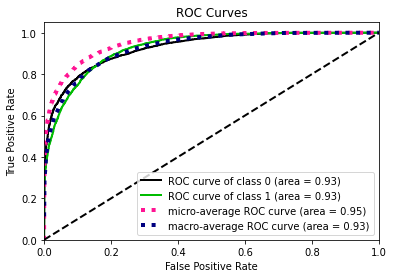

In [ ]:
plot_roc(y_test, predictions_probs)

In [ ]:
roc_auc_score(y_test, predictions_probs[:,1])

0.9280263506479142